Phan tich cac cls model

📂 Sử dụng thư mục mô hình: models/classtification
doc toi day : data/raw/global_placement.csv
Preprocessing completed. Scalers saved.
🚀 Đang khởi chạy đánh giá chuyên sâu...



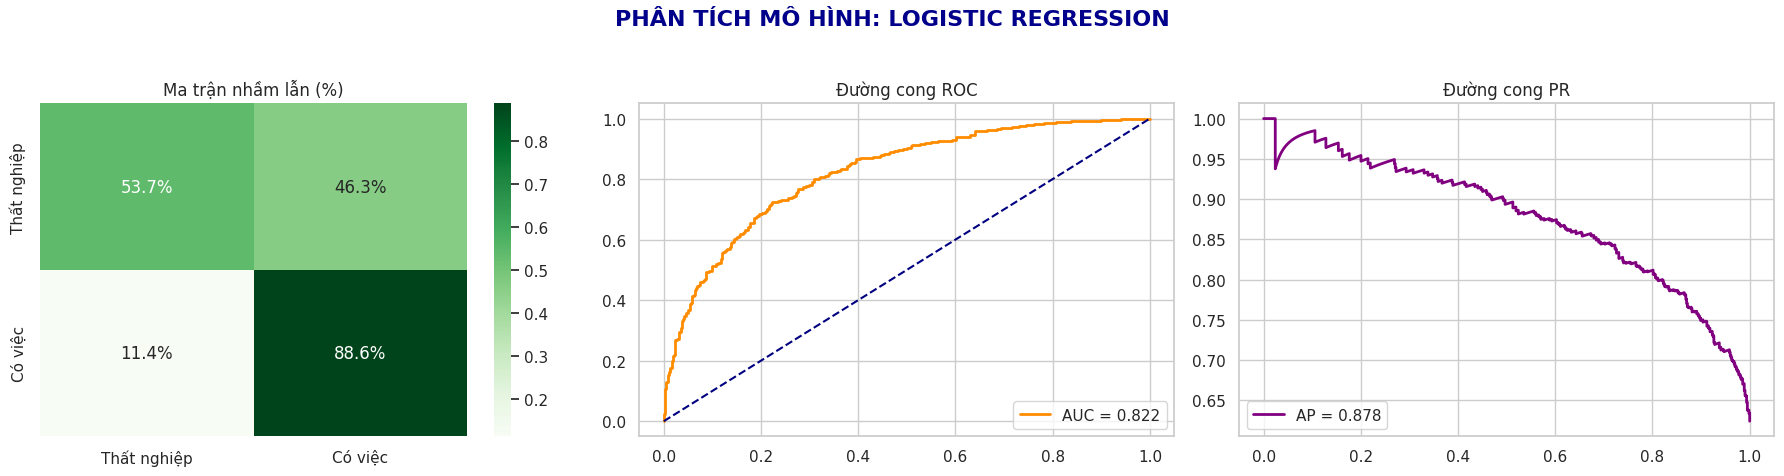

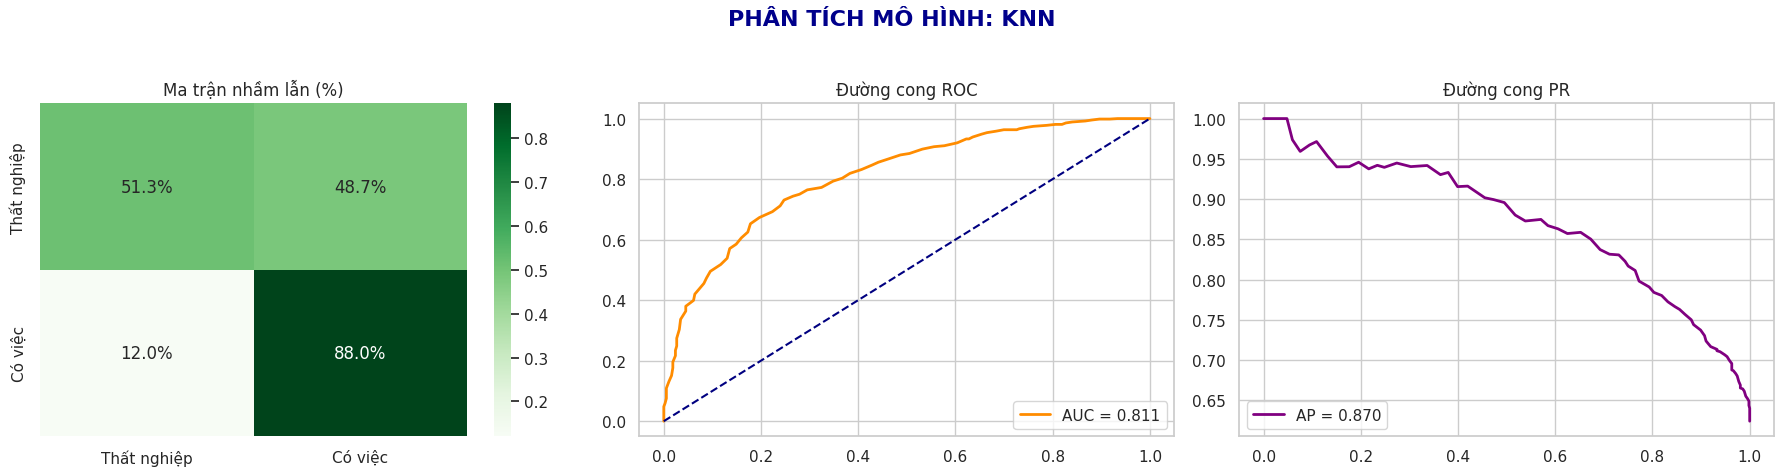

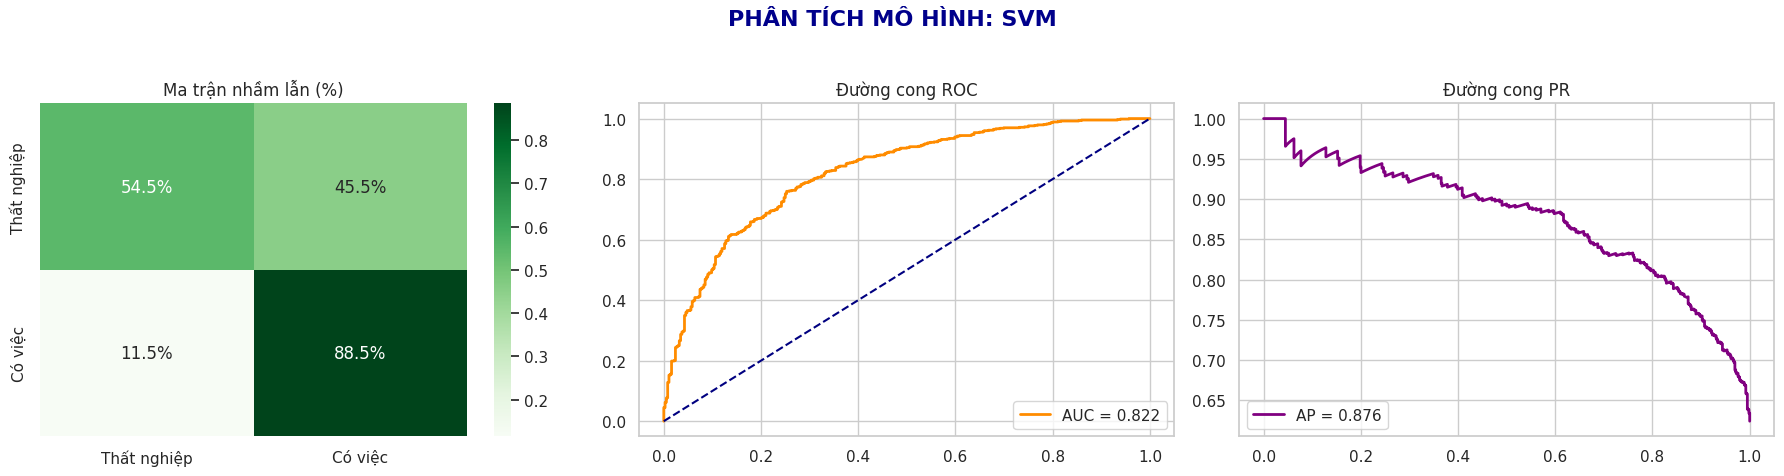

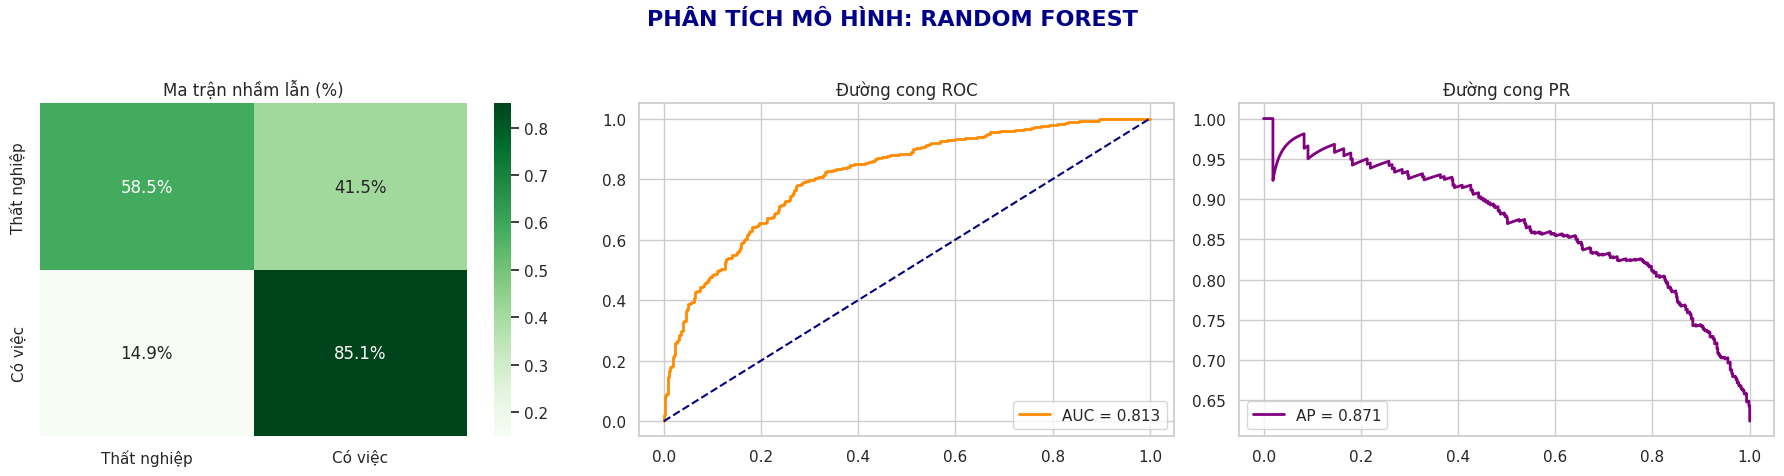

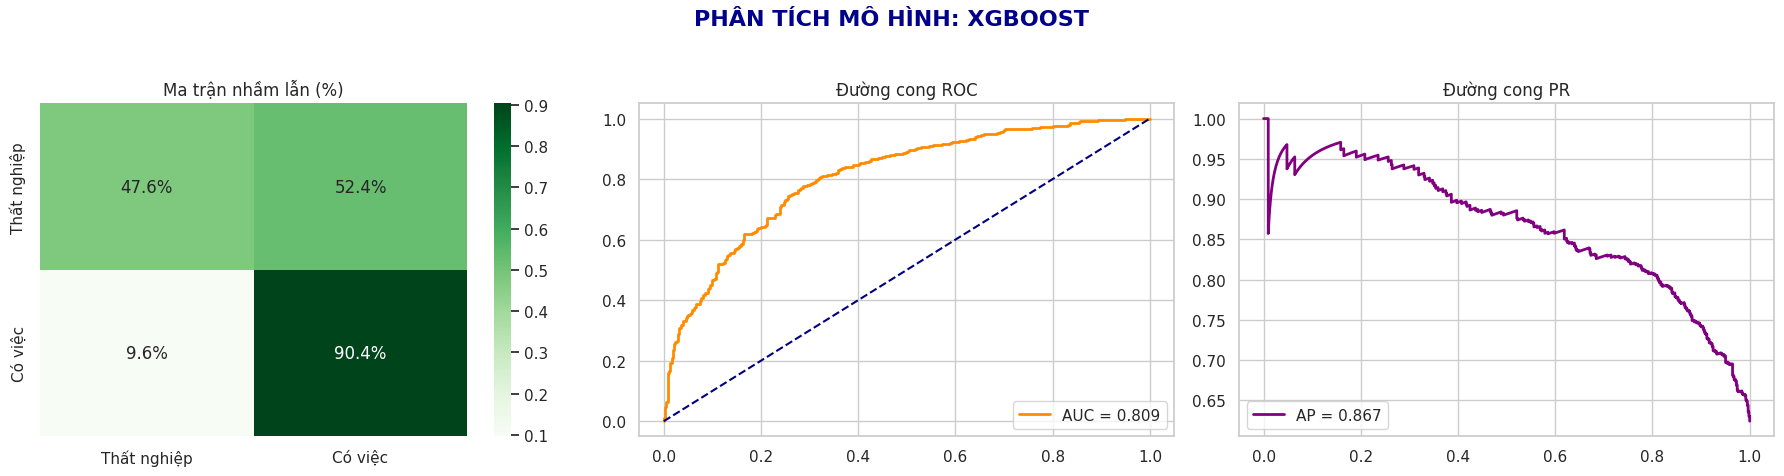

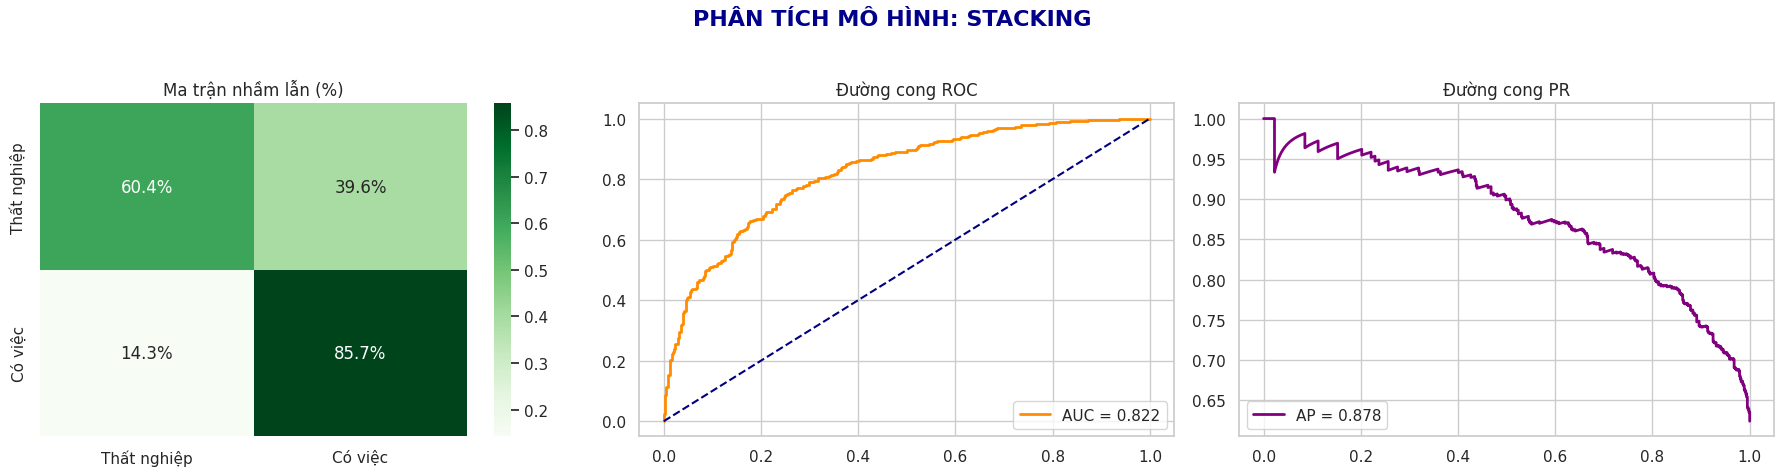


BẢNG TỔNG KẾT HIỆU NĂNG TOÀN BỘ MÔ HÌNH


,Model,Accuracy,F1-Score,ROC-AUC
5,Stacking,0.762000,0.757141,0.821698
2,SVM,0.757000,0.747509,0.822452
3,Random Forest,0.751000,0.745599,0.812675
0,Logistic Regression,0.755000,0.744898,0.821889
1,KNN,0.742000,0.730641,0.810865
4,XGBoost,0.743000,0.727086,0.809214


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import sys
import pandas as pd
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc, 
    precision_recall_curve, average_precision_score, accuracy_score, f1_score
)
from src.data.preprocess_classtification import preprocess_data_cls

# --- 1. ĐỒNG BỘ MÔI TRƯỜNG ---
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

# --- 2. XÁC ĐỊNH ĐƯỜNG DẪN THỰC TẾ ---
# Dựa trên log check path của ông, hãy dùng biến actual_path đã tìm thấy
possible_paths = ['models/classtification', 'models/classification']
model_dir = None

for p in possible_paths:
    if os.path.exists(p):
        model_dir = p
        break

if not model_dir:
    # Nếu vẫn không thấy, ép về cái tên folder trong ảnh folder ông chụp lúc nãy
    model_dir = 'models/classtification' 

print(f"📂 Sử dụng thư mục mô hình: {model_dir}")
(X_train, X_val, X_test_cls, y_train, y_val, y_test_cls)= preprocess_data_cls("data/raw/global_placement.csv")

# --- 3. DANH SÁCH FILE (Cập nhật cả SVM) ---
model_files = {
    'Logistic Regression': 'logistic_regression_model.joblib',
    'KNN': 'knn_model.joblib',
    'SVM': 'svm_model.joblib',
    'Random Forest': 'random_forest_model.joblib',
    'XGBoost': 'xgboost_model.joblib',
    'Stacking': 'stacking_model.joblib',
}

results_summary = []
sns.set_theme(style="whitegrid")

print(f"🚀 Đang khởi chạy đánh giá chuyên sâu...\n")

for model_name, file_name in model_files.items():
    model_path = os.path.join(model_dir, file_name)
    
    if not os.path.exists(model_path):
        print(f"⚠️ Bỏ qua {model_name}: Không tìm thấy file tại {model_path}")
        continue

    # 1. Load và Dự đoán
    model = joblib.load(model_path)
    y_pred = model.predict(X_test_cls)
    
    # Một số model cần probability=True mới có predict_proba (như SVM)
    y_prob = None
    if hasattr(model, "predict_proba"):
        try:
            y_prob = model.predict_proba(X_test_cls)[:, 1]
        except:
            y_prob = None

    # 2. Vẽ Dashboard
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'PHÂN TÍCH MÔ HÌNH: {model_name.upper()}', fontsize=16, fontweight='bold', color='darkblue')

    # Ma trận nhầm lẫn
    cm_norm = confusion_matrix(y_test_cls, y_pred, normalize='true')
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Greens', ax=axes[0],
                xticklabels=['Thất nghiệp', 'Có việc'], yticklabels=['Thất nghiệp', 'Có việc'])
    axes[0].set_title('Ma trận nhầm lẫn (%)')

    roc_auc = 0
    if y_prob is not None:
        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test_cls, y_prob)
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
        axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
        axes[1].set_title('Đường cong ROC')
        axes[1].legend(loc="lower right")

        # PR Curve
        prec, rec, _ = precision_recall_curve(y_test_cls, y_prob)
        ap = average_precision_score(y_test_cls, y_prob)
        axes[2].plot(rec, prec, color='purple', lw=2, label=f'AP = {ap:.3f}')
        axes[2].set_title('Đường cong PR')
        axes[2].legend(loc="lower left")
    else:
        axes[1].text(0.5, 0.5, 'N/A (No Probs)', ha='center', va='center')
        axes[2].text(0.5, 0.5, 'N/A (No Probs)', ha='center', va='center')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # 3. Lưu kết quả
    results_summary.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test_cls, y_pred),
        'F1-Score': f1_score(y_test_cls, y_pred, average='weighted'),
        'ROC-AUC': roc_auc
    })

# --- HIỂN THỊ TỔNG KẾT ---
print("\n" + "="*50)
print("BẢNG TỔNG KẾT HIỆU NĂNG TOÀN BỘ MÔ HÌNH")
print("="*50)
df_final = pd.DataFrame(results_summary).sort_values(by='F1-Score', ascending=False)
display(df_final.style.highlight_max(axis=0, color='lightgreen'))

✅ Đang đứng tại: /home/anhphan/CTU/Machine Learning/Project/student-placement-ml
Preprocessing regression data completed. Scalers saved.


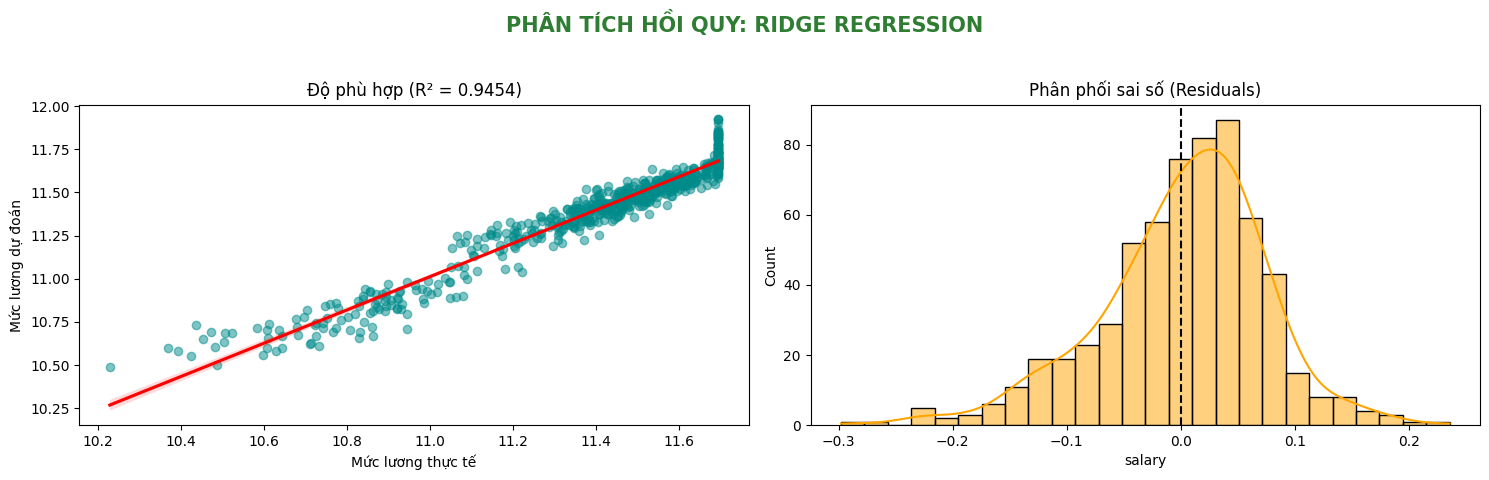

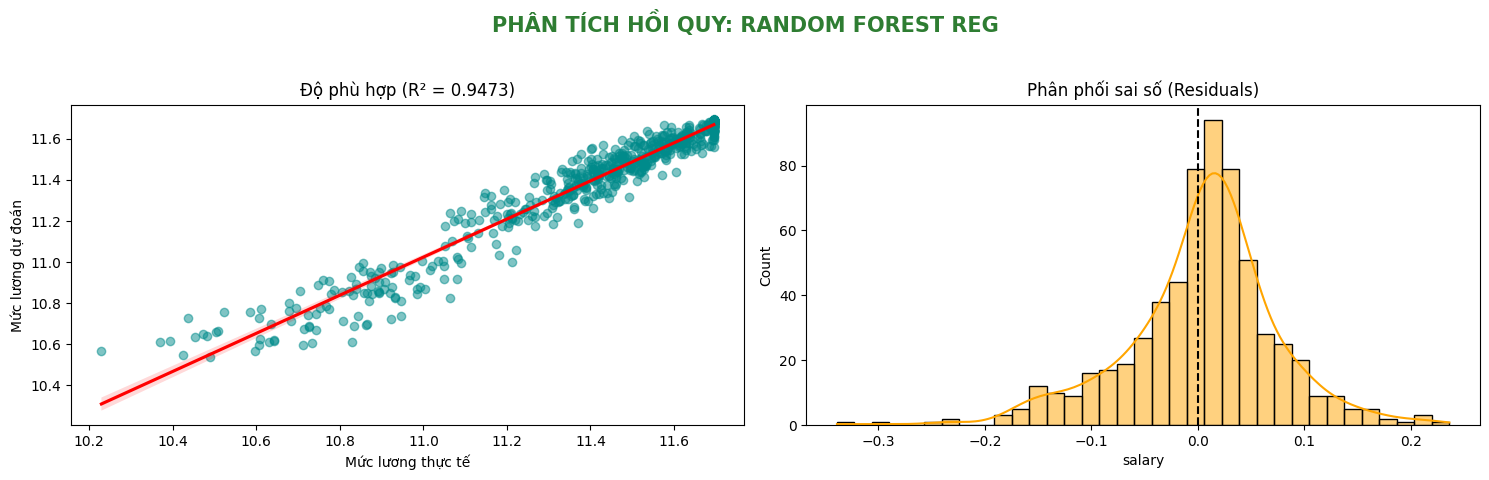

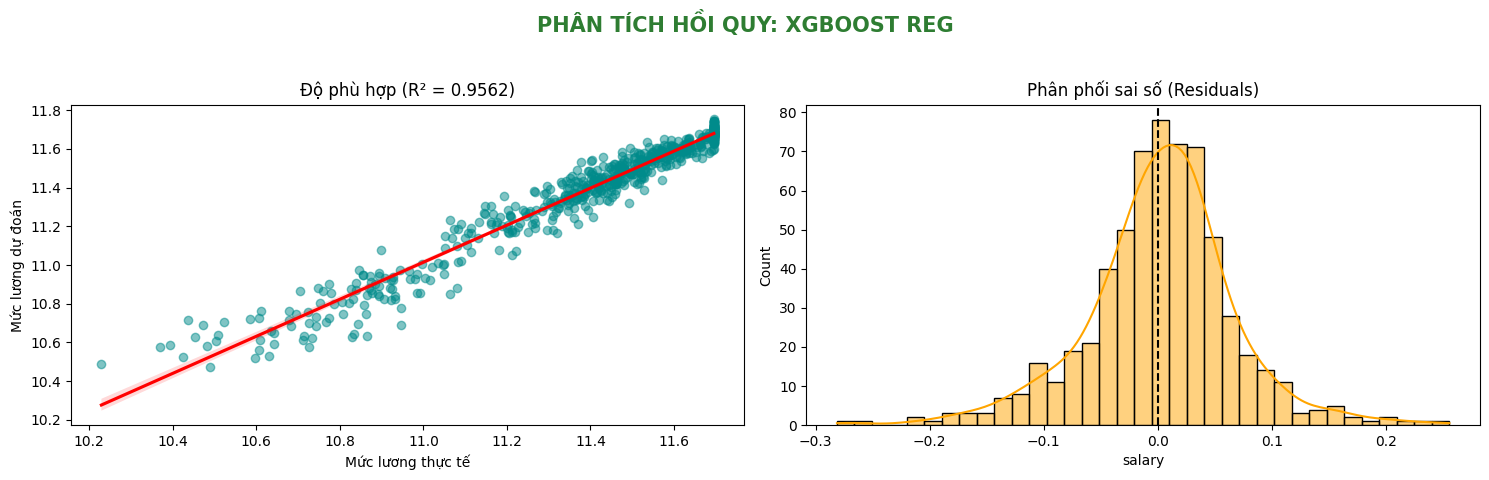

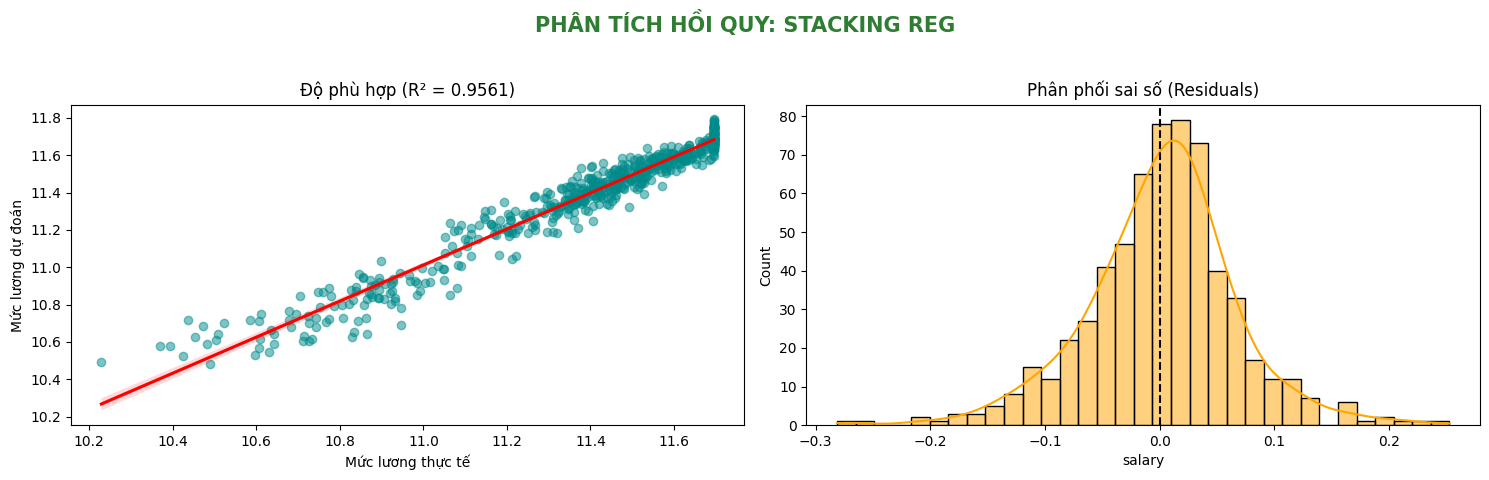


BẢNG SO SÁNH HIỆU NĂNG REGRESSION


,Model,MAE,RMSE,R2 Score
2,XGBoost Reg,0.05,0.07,0.9562
3,Stacking Reg,0.05,0.07,0.9561
1,Random Forest Reg,0.05,0.07,0.9473
0,Ridge Regression,0.06,0.07,0.9454


In [3]:
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================================
# BƯỚC 1: FIX PATH DỰA TRÊN CẤU TRÚC THƯ MỤC CỦA BẠN
# =====================================================================
# Lùi ra khỏi folder 'notebooks' để về gốc 'STUDENT-PLACEMENT-ML'
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

# Thêm thư mục hiện tại vào sys.path để nhận diện folder 'src'
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print(f"✅ Đang đứng tại: {os.getcwd()}")

# Bây giờ import sẽ chạy mượt mà
from src.data.preprocess_regression import preprocess_data_reg

# =====================================================================
# BƯỚC 2: CẤU HÌNH ĐƯỜNG DẪN
# =====================================================================
model_dir_reg = 'models/regression/' 
csv_path = "data/raw/global_placement.csv" 

# Đảm bảo thư mục lưu trữ tồn tại (để tránh lỗi OSError bên trong hàm preprocess)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)

model_files_reg = {
    'Ridge Regression': 'ridge_regression.joblib',
    'Random Forest Reg': 'random_forest_reg_model.joblib',
    'XGBoost Reg': 'xgboost_reg_model.joblib',
    'Stacking Reg': 'stacking_reg_model.joblib',
}

# =====================================================================
# BƯỚC 3: LOAD DỮ LIỆU & ĐÁNH GIÁ
# =====================================================================
# Gọi hàm của bạn (Anh Phan lưu ý: Biến nhận về phải khớp với vòng lặp bên dưới)
(X_train, X_val, X_test_reg, y_train, y_val, y_test_reg) = preprocess_data_reg(csv_path)

reg_results = []

for model_name, file_name in model_files_reg.items():
    model_path = os.path.join(model_dir_reg, file_name)
    
    if os.path.exists(model_path):
        model = joblib.load(model_path)
        y_pred = model.predict(X_test_reg)
        
        # Tính toán chỉ số
        mae = mean_absolute_error(y_test_reg, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
        r2 = r2_score(y_test_reg, y_pred)
        
        reg_results.append({
            'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2 Score': r2
        })
        
        # Vẽ Dashboard so sánh
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle(f'PHÂN TÍCH HỒI QUY: {model_name.upper()}', fontsize=15, fontweight='bold', color='#2E7D32')

        # Biểu đồ Thực tế vs Dự đoán
        sns.regplot(x=y_test_reg, y=y_pred, ax=axes[0], 
                    scatter_kws={'alpha':0.5, 'color':'darkcyan'}, 
                    line_kws={'color':'red', 'label':'Lý tưởng'})
        axes[0].set_title(f'Độ phù hợp (R² = {r2:.4f})')
        axes[0].set_xlabel('Mức lương thực tế')
        axes[0].set_ylabel('Mức lương dự đoán')

        # Biểu đồ sai số (Residuals)
        residuals = y_test_reg - y_pred
        sns.histplot(residuals, kde=True, ax=axes[1], color='orange')
        axes[1].axvline(0, color='black', linestyle='--')
        axes[1].set_title('Phân phối sai số (Residuals)')
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
    else:
        print(f"⚠️ Bỏ qua {model_name}: Không tìm thấy file tại {model_path}")

# =====================================================================
# BẢNG TỔNG KẾT CUỐI CÙNG
# =====================================================================
print("\n" + "="*50)
print("BẢNG SO SÁNH HIỆU NĂNG REGRESSION")
print("="*50)
df_final = pd.DataFrame(reg_results).sort_values(by='R2 Score', ascending=False)
display(df_final.style.format({'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'R2 Score': '{:.4f}'})
        .background_gradient(subset=['R2 Score'], cmap='RdYlGn'))